In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plays = pd.read_csv('fbs_fbs_wildcats.csv')

C:\Users\bchm5\AppData\Local\Temp\ipykernel_26864\2388058343.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv('fbs_fbs_wildcats.csv')


In [9]:
# plays['wildcat_position'].unique()

plays.loc[:, 'first_down_gained_numeric'] = \
    plays['first_down_gained'].fillna(0)

# set wildcats
wildcats = plays[plays['wildcat_play'] == 1]

# set te
te_wildcats = wildcats[wildcats['wildcat_position'] == 'TE']

# short runs
short_3_4_run_wildcats = wildcats[(wildcats['play_type'] == 'designed run') & (wildcats['distance'] <= 3) & (wildcats['down'].isin([3, 4]))]

# passes
pass_wildcats = wildcats[wildcats['play_type'] == 'dropback']

wildcat_position = wildcats.groupby(['wildcat_position']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean'),
    most_common_play=('play_type', lambda x: x.mode()[0])
).reset_index().sort_values('plays', ascending=False)

short_run_wildcats_position = short_3_4_run_wildcats.groupby(['wildcat_position']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean'),
    # most_common_play=('play_type', lambda x: x.mode()[0])
).reset_index().sort_values('plays', ascending=False)

print("Overall:", short_3_4_run_wildcats['first_down_gained_numeric'].mean())
short_run_wildcats_position

Overall: 0.649402390438247


,wildcat_position,plays,first_down_rate
0,HB,181,0.624309
3,TE,56,0.714286
4,WR,11,0.636364
1,ST,2,1.000000
2,T,1,1.000000


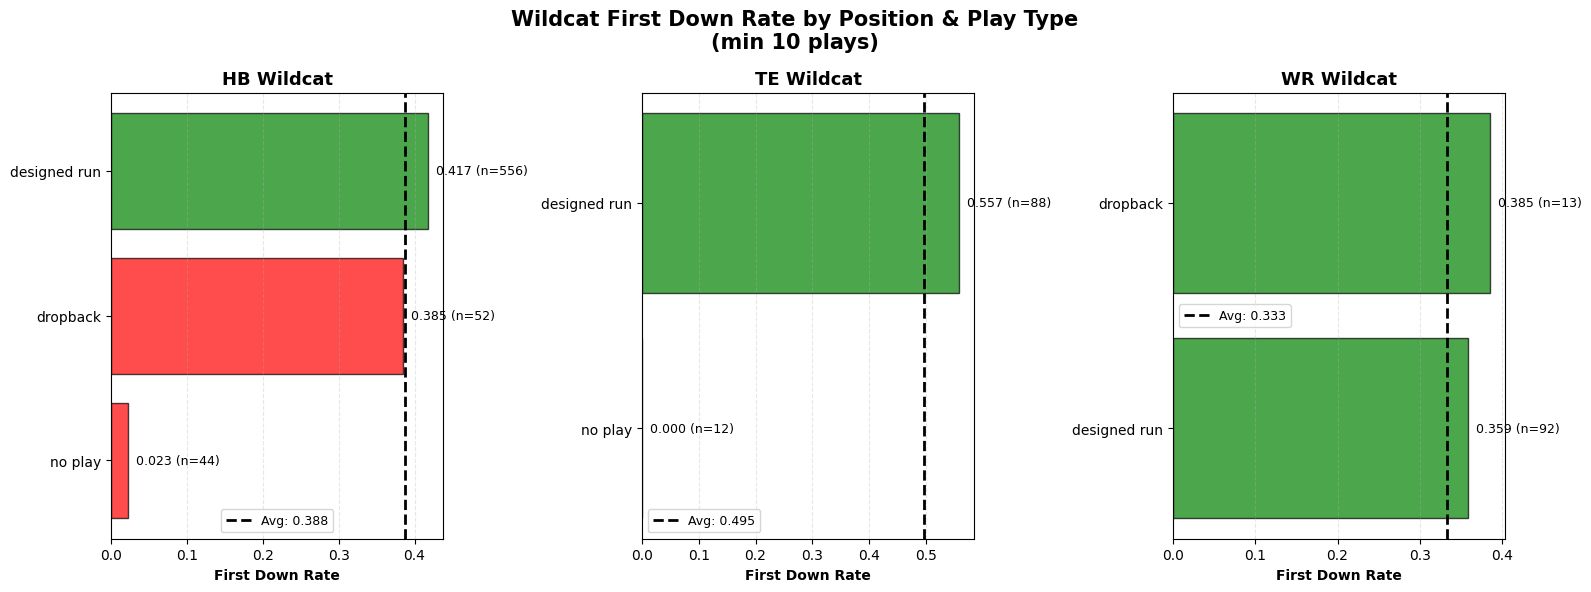

In [18]:
min_plays = 10  # adjust threshold as needed

filtered = wildcats[wildcats['wildcat_position'].isin(['HB', 'WR', 'TE'])]

plot_data = filtered.groupby(['wildcat_position', 'play_type']).agg(
    plays=('wildcat_play', 'size'),
    first_down_rate=('first_down_gained_numeric', 'mean')
).reset_index()

plot_data = plot_data[plot_data['plays'] >= min_plays]

positions = plot_data['wildcat_position'].unique()
fig, axes = plt.subplots(1, len(positions), figsize=(16, 6), sharey=False)

for ax, position in zip(axes, positions):
    pos_data = plot_data[plot_data['wildcat_position'] == position].sort_values('first_down_rate', ascending=True)
    
    overall_avg = filtered[filtered['wildcat_position'] == position]['first_down_gained_numeric'].mean()
    
    colors = ['green' if r > overall_avg else 'red' for r in pos_data['first_down_rate']]
    
    bars = ax.barh(pos_data['play_type'], pos_data['first_down_rate'], color=colors, alpha=0.7, edgecolor='black')
    
    for bar, (_, row) in zip(bars, pos_data.iterrows()):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f"  {row['first_down_rate']:.3f} (n={row['plays']})",
                va='center', fontsize=9)
    
    ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2, label=f'Avg: {overall_avg:.3f}')
    ax.set_title(f'{position} Wildcat', fontweight='bold', fontsize=13)
    ax.set_xlabel('First Down Rate', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle(f'Wildcat First Down Rate by Position & Play Type\n(min {min_plays} plays)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

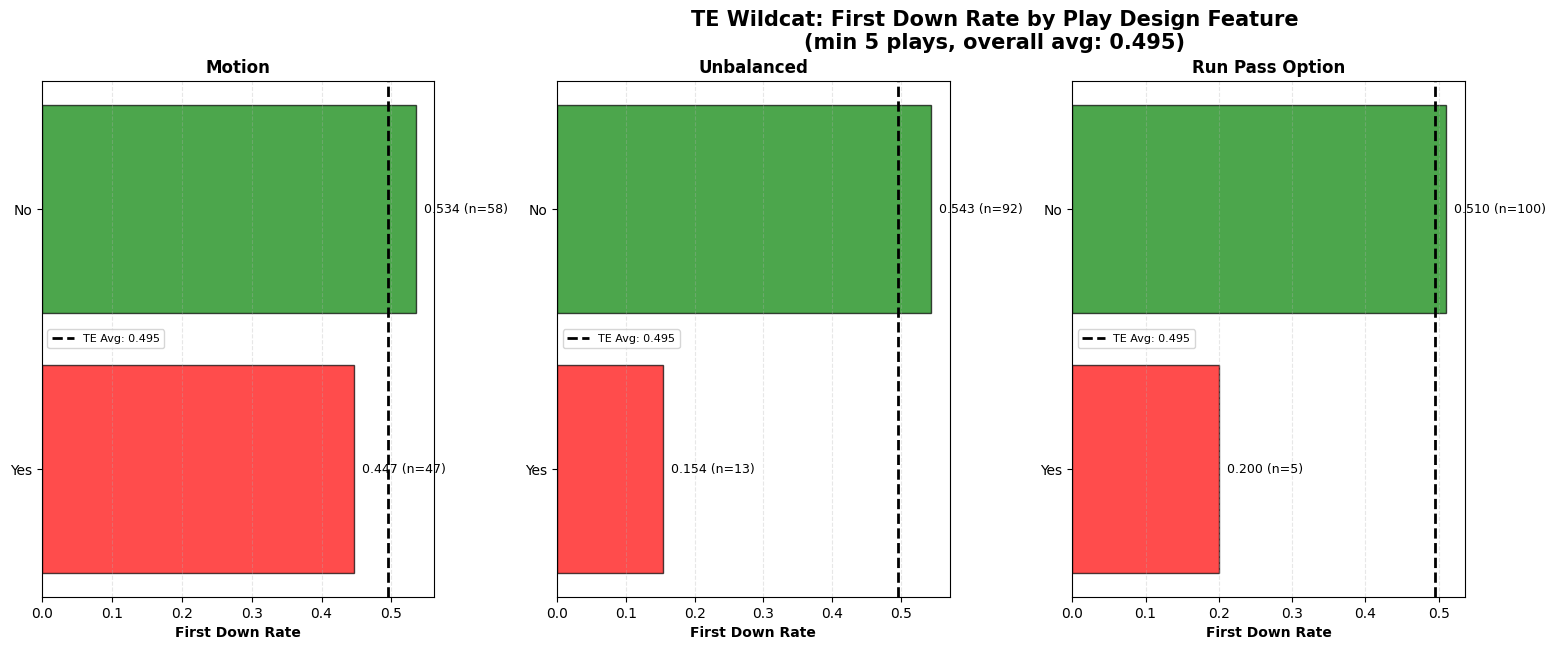

In [24]:
min_plays = 5  # lower threshold given smaller sample

overall_avg = te_wildcats['first_down_gained_numeric'].mean()

design_features = ['motion', 'unbalanced', 'run_pass_option']

plot_data = {}
for feature in design_features:
    grouped = te_wildcats.groupby(feature).agg(
        plays=('wildcat_play', 'size'),
        first_down_rate=('first_down_gained_numeric', 'mean')
    ).reset_index()
    grouped = grouped[grouped['plays'] >= min_plays]
    grouped['feature'] = feature
    grouped.rename(columns={feature: 'value'}, inplace=True)
    plot_data[feature] = grouped
    grouped['value'] = grouped['value'].map({0: 'No', 1: 'Yes'})

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for i, (feature, data) in enumerate(plot_data.items()):
    ax = axes[i]
    data = data.sort_values('first_down_rate', ascending=True)
    
    colors = ['green' if r > overall_avg else 'red' for r in data['first_down_rate']]
    bars = ax.barh(data['value'].astype(str), data['first_down_rate'], 
                   color=colors, alpha=0.7, edgecolor='black')
    
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f"  {row['first_down_rate']:.3f} (n={row['plays']})",
                va='center', fontsize=9)
    
    ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2, 
               label=f'TE Avg: {overall_avg:.3f}')
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=12)
    ax.set_xlabel('First Down Rate', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

# hide unused subplots
for j in range(len(plot_data), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'TE Wildcat: First Down Rate by Play Design Feature\n(min {min_plays} plays, overall avg: {overall_avg:.3f})',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

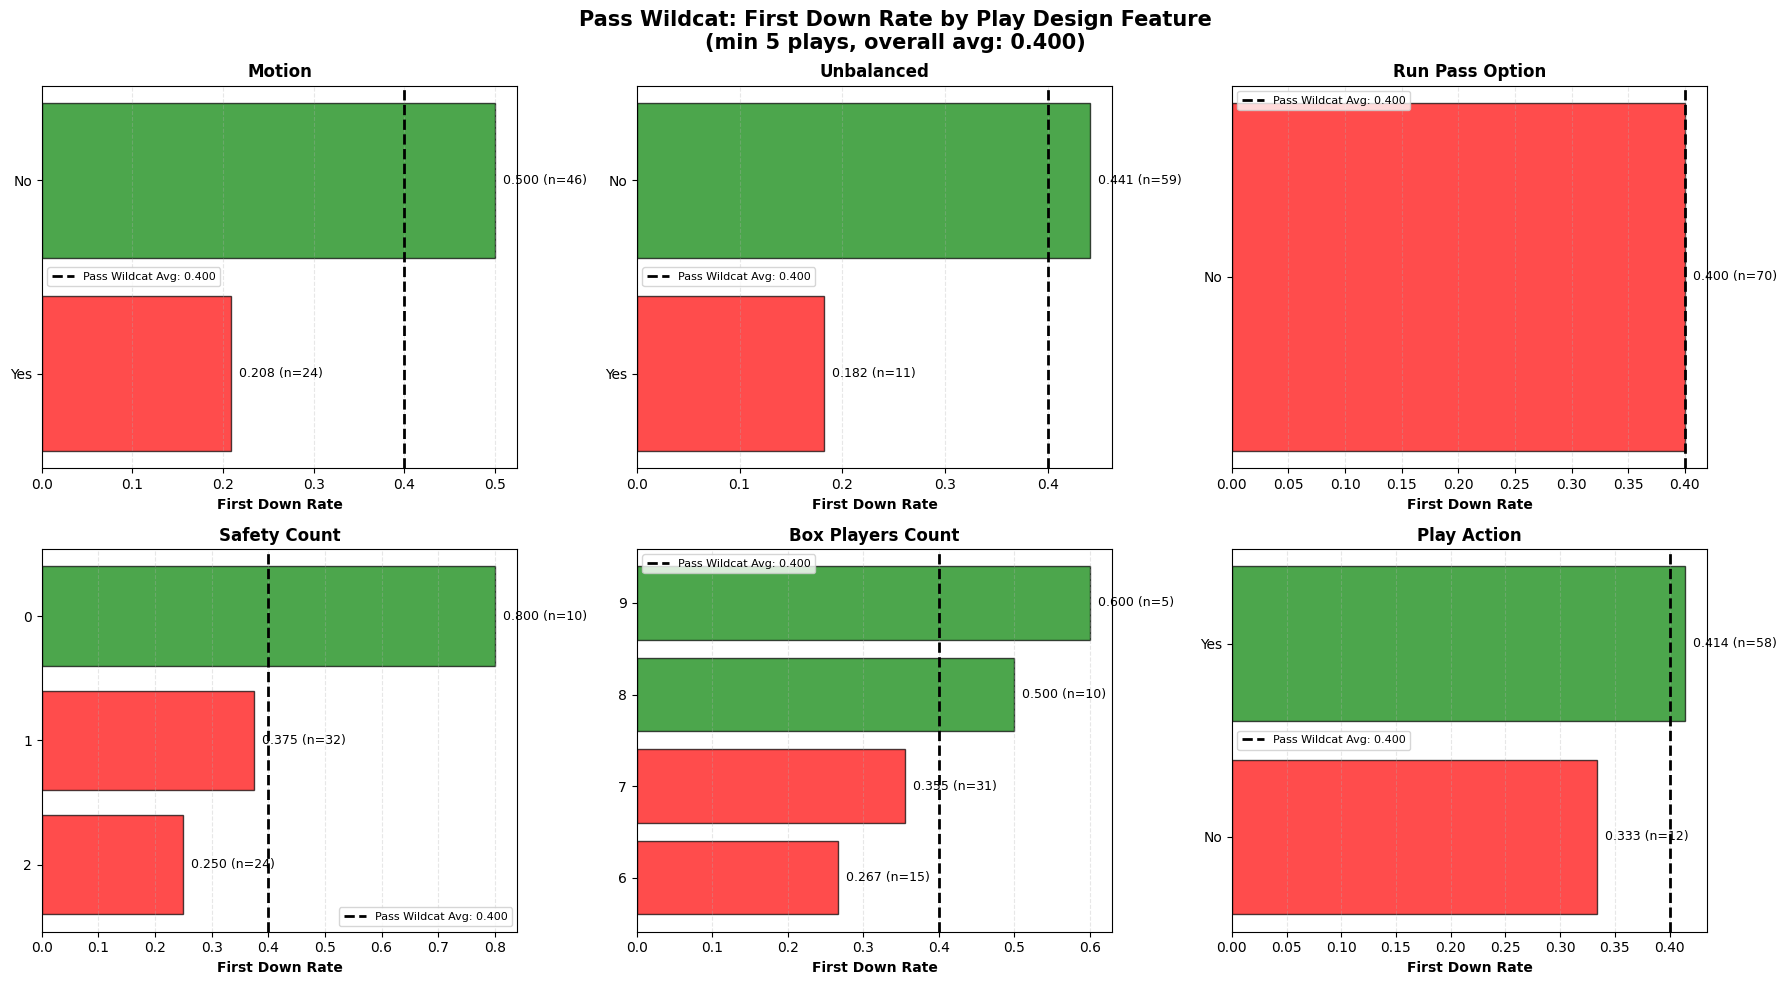

In [32]:
min_plays = 5

overall_avg = pass_wildcats['first_down_gained_numeric'].mean()

design_features = ['motion', 'unbalanced', 'run_pass_option', 'safety_count', 'box_players_count', 'play_action']

plot_data = {}
for feature in design_features:
    grouped = pass_wildcats.groupby(feature).agg(
        plays=('wildcat_play', 'size'),
        first_down_rate=('first_down_gained_numeric', 'mean')
    ).reset_index()
    grouped = grouped[grouped['plays'] >= min_plays]
    grouped['feature'] = feature
    grouped.rename(columns={feature: 'value'}, inplace=True)
    # only map binary features
    if feature in ['motion', 'unbalanced', 'run_pass_option', 'play_action']:
        grouped['value'] = grouped['value'].map({0: 'No', 1: 'Yes'})
    plot_data[feature] = grouped

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (feature, data) in enumerate(plot_data.items()):
    ax = axes[i]
    data = data.sort_values('first_down_rate', ascending=True)
    
    colors = ['green' if r > overall_avg else 'red' for r in data['first_down_rate']]
    bars = ax.barh(data['value'].astype(str), data['first_down_rate'], 
                   color=colors, alpha=0.7, edgecolor='black')
    
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f"  {row['first_down_rate']:.3f} (n={row['plays']})",
                va='center', fontsize=9)
    
    ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2, 
               label=f'Pass Wildcat Avg: {overall_avg:.3f}')
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold', fontsize=12)
    ax.set_xlabel('First Down Rate', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

for j in range(len(plot_data), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Pass Wildcat: First Down Rate by Play Design Feature\n(min {min_plays} plays, overall avg: {overall_avg:.3f})',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()